# Week 06: Stats for Business: Is the Price Right?

You just joined the pricing team at a car-listing marketplace. Your manager has a few questions and one rule: **every claim needs a number, and every number needs a reason to trust it.**

**Data:** `cars.csv`: about 12,000 car trims (1990–2017) with specs and sticker price (MSRP). Source: [Car Features and MSRP (Kaggle)](https://www.kaggle.com/datasets/CooperUnion/cardataset). It's real data, so it's messy.

**What you'll practice** (all from this week's lecture):
- Cleaning before describing
- Mean vs median, skew, log transforms
- z-scores
- Bootstrap confidence intervals
- One- and two-sample tests, and picking the right one
- Confounding, and significant vs important

**How to answer:** Fill in the code cells, then write 1–3 sentences in each **Answer:** cell. Code without an interpretation is only half the job.

Plan for about 2–3 hours. 🚀 questions are optional stretch.

## Setup

In [1]:
# run this first if you dont have them installed in your env
!pip install pandas numpy matplotlib scipy

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.max_columns", None)
rng = np.random.default_rng(42)  # use rng for all random sampling so your results are reproducible

df = pd.read_csv("../data/cars.csv")
print(df.shape)
df.head()

(11914, 15)


,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Convertible,28,18,3916,34500


---
## Part 1: Can you trust this data?

### Q1. Find the problems before you average anything

This dataset has **at least five** real problems. Find them, fix or flag each one, and build a cleaned DataFrame called `clean`. You'll use `clean` for the rest of the notebook.

Use your Week 02 cleaning checklist. Some nudges, in no particular order:
- Count things twice.
- The most common value in a column can be more suspicious than the largest one.
- Would you print every max value in a sales brochure?
- Missing values usually have a reason. *Who* is missing?
- Is every number in a column measured in the same unit?
- Does every column vary at the level you'd expect?
- Not everything weird is wrong.

For each problem, decide: **drop it, set it to NaN, flag it, or leave it**. Dropping whole rows is the last resort, because a row with a bad price may still have a good MPG.

In [10]:
print("exact duplicate rows:", df.duplicated().sum())
print(df.isna().sum()[df.isna().sum() > 0])
print(df.describe())

exact duplicate rows: 720
Engine Fuel Type     3
Engine HP           69
Engine Cylinders    30
Number of Doors      6
dtype: int64
               Year    Engine HP  Engine Cylinders  Number of Doors  \
count  11914.000000  11845.00000      11884.000000     11908.000000   
mean    2010.384338    249.38607          5.628829         3.436093   
std        7.579740    109.19187          1.780559         0.881315   
min     1990.000000     55.00000          0.000000         2.000000   
25%     2007.000000    170.00000          4.000000         2.000000   
50%     2015.000000    227.00000          6.000000         4.000000   
75%     2016.000000    300.00000          6.000000         4.000000   
max     2017.000000   1001.00000         16.000000         4.000000   

        highway MPG      city mpg    Popularity          MSRP  
count  11914.000000  11914.000000  11914.000000  1.191400e+04  
mean      26.637485     19.733255   1554.911197  4.059474e+04  
std        8.863001      8.987798   1

In [14]:
print("MSRP == 2000:", (df["MSRP"] == 2000).sum())
print(df["MSRP"].value_counts().head(5), "\n")
print(df.loc[df["MSRP"] == 2000].groupby("Year").size().to_string())

MSRP == 2000: 1036
MSRP
2000     1036
25995      19
29995      19
20995      16
27995      16
Name: count, dtype: int64 

Year
1990    117
1991    137
1992    161
1993    171
1994    134
1995     91
1996     90
1997     68
1998     32
1999     20
2000     15


In [15]:
print(df.nlargest(6, "MSRP")[["Make", "Model", "Year", "MSRP", "Engine HP"]])

              Make        Model  Year     MSRP  Engine HP
11362      Bugatti  Veyron 16.4  2008  2065902     1001.0
11364      Bugatti  Veyron 16.4  2009  1705769     1001.0
8486   Lamborghini     Reventon  2008  1500000      650.0
11363      Bugatti  Veyron 16.4  2008  1500000     1001.0
6351       Maybach    Landaulet  2012  1382750      620.0
6350       Maybach    Landaulet  2011  1380000      620.0


In [18]:
print(df.loc[df["highway MPG"] > 100, ["Make", "Model", "Year", "Engine Fuel Type", "highway MPG", "city mpg"]].head(8))
print(df.loc[df["highway MPG"] > 100, "Engine Fuel Type"].value_counts())

            Make    Model  Year                Engine Fuel Type  highway MPG  \
539         FIAT     500e  2015                        electric          108   
540         FIAT     500e  2016                        electric          103   
541         FIAT     500e  2017                        electric          103   
1119        Audi       A6  2017  premium unleaded (recommended)          354   
1983   Chevrolet  Bolt EV  2017                        electric          110   
1984   Chevrolet  Bolt EV  2017                        electric          110   
3716  Volkswagen   e-Golf  2015                        electric          105   
3717  Volkswagen   e-Golf  2015                        electric          105   

      city mpg  
539        122  
540        121  
541        121  
1119        24  
1983       128  
1984       128  
3716       126  
3717       126  
Engine Fuel Type
electric                          40
premium unleaded (recommended)     1
Name: count, dtype: int64


In [19]:
print(df["Transmission Type"].value_counts(), "\n")
print("Missing HP by fuel type:\n", df.loc[df["Engine HP"].isna(), "Engine Fuel Type"].value_counts(), "\n")
print("Cylinders == 0:", (df["Engine Cylinders"] == 0).sum())
print("Max # of distinct Popularity values within one Make:", df.groupby("Make")["Popularity"].nunique().max(), "\n")
print(df["Year"].value_counts().sort_index().to_string())

Transmission Type
AUTOMATIC           8266
MANUAL              2935
AUTOMATED_MANUAL     626
DIRECT_DRIVE          68
UNKNOWN               19
Name: count, dtype: int64 

Missing HP by fuel type:
 Engine Fuel Type
electric                            44
regular unleaded                    14
flex-fuel (unleaded/natural gas)     6
premium unleaded (recommended)       4
diesel                               1
Name: count, dtype: int64 

Cylinders == 0: 56
Max # of distinct Popularity values within one Make: 1 

Year
1990     123
1991     152
1992     177
1993     209
1994     163
1995     135
1996     131
1997     175
1998     154
1999     120
2000     118
2001     168
2002     205
2003     238
2004     235
2005     213
2006     205
2007     345
2008     349
2009     379
2010     298
2011     285
2012     387
2013     366
2014     589
2015    2170
2016    2157
2017    1668


**Cleaning log:** (row counts are after the exact duplicates were removed, except row 1)

| # | Problem | How I found it | Rows affected | What I did | Why |
|---|---|---|---|---|---|
| 1 | Exact duplicate rows | `df.duplicated().sum()` | 720 | Dropped | Same car counted twice would inflate every count and bias every average; the only rows I drop. |
| 2 | `msrp == 2000` placeholder | `value_counts()` showed 2000 appears 1,036 times (next most common price: 19); all are 1990-2000 cars | 1,036 raw / 747 after dedupe | Set `msrp` to NaN | $2,000 is a fake default, not a real sticker price. Setting NaN keeps the row's MPG, HP, etc. usable. |
| 3 | Electric cars report MPGe, not MPG | `highway MPG > 100` was all `electric` fuel type (Tesla, Leaf, Bolt...) | 66 | Added `is_electric` flag, set both MPG columns to NaN | MPGe is a different unit (energy equivalent), so averaging it with gas MPG is meaningless. |
| 4 | Impossible highway MPG of 354 | `nlargest` / `describe()`: max 354 vs. city 24 on a gas Audi A6 | 1 | Set `highway_mpg` to NaN | An obvious typo (probably 35 or 35.4). I can't know the true value, so I don't guess. |
| 5 | `UNKNOWN` transmission type | `value_counts()` on transmission | 19 raw / 12 after dedupe | Set to NaN | It is a missing value in disguise, and would show up as its own "category" otherwise. |
| 6 | `popularity` doesn't vary by trim | `groupby("make")["popularity"].nunique()` max is 1: one value per make | all rows | Dropped the column | It is a make-level number copied onto every row, so using it per car would be misleading. |
| 7 | `engine_cylinders == 0` | `describe()` min of 0 (electric / rotary engines) | 56 | Set to NaN | 0 cylinders isn't a real count and would drag averages down. |
| - | Left alone | Bugatti / Lamborghini / Maybach prices up to $2.07M; missing HP (mostly electrics); 2015-17 are ~half the rows | - | Kept | Extreme but real; "not everything weird is wrong". The year imbalance matters later (Q6). |

In [20]:
clean = df.copy()
clean.columns = clean.columns.str.strip().str.lower().str.replace(" ", "_") 

In [21]:
clean = clean.drop_duplicates()

In [22]:
clean.loc[clean["msrp"] == 2000, "msrp"] = np.nan

In [23]:
clean["is_electric"] = clean["engine_fuel_type"].eq("electric")
clean.loc[clean["is_electric"], ["highway_mpg", "city_mpg"]] = np.nan

In [24]:
clean.loc[clean["highway_mpg"] > 100, "highway_mpg"] = np.nan

In [25]:
clean.loc[clean["transmission_type"] == "UNKNOWN", "transmission_type"] = np.nan

In [26]:
clean = clean.drop(columns="popularity")

In [27]:
clean.loc[clean["engine_cylinders"] == 0, "engine_cylinders"] = np.nan

In [28]:
# Checkpoint: run this before moving on.
print(clean.shape)
print(clean.isna().sum()[clean.isna().sum() > 0])
# Fewer than ~10,000 rows? You probably dropped too much. Go back and use NaN or a flag instead.

(11194, 15)
engine_fuel_type       3
engine_hp             69
engine_cylinders      86
transmission_type     12
number_of_doors        6
highway_mpg           67
city_mpg              66
msrp                 747
dtype: int64


---
## Part 2: Describe

### Q2. What does a "typical" car cost?

Your manager wants one number for "typical price" on the homepage.

a) Compute the mean and median MSRP. Which is bigger, and why?

b) Plot a histogram of MSRP, then a histogram of `np.log10(msrp)`. Describe each shape in a few words.

c) What percent of cars cost more than the mean?

d) Which number belongs on the homepage? Why?

In [42]:
mean_median = round(clean['msrp'].agg(['mean', 'median']), 0)
mean_median

mean      44789.0
median    31870.0
Name: msrp, dtype: float64

In [46]:
price = clean["msrp"].dropna()
mean_p, median_p = price.mean(), price.median()
print(f"n = {len(price):,}   mean = ${mean_p:,.0f}   median = ${median_p:,.0f}   mean/median = {mean_p/median_p:.2f}")

n = 10,447   mean = $44,789   median = $31,870   mean/median = 1.41


In [66]:
price = clean['msrp'].dropna()
mean_price = price.mean()
print(f"{(price> mean_price).mean():.2%} of cars cost more than the mean")

24.45% of cars cost more than the mean


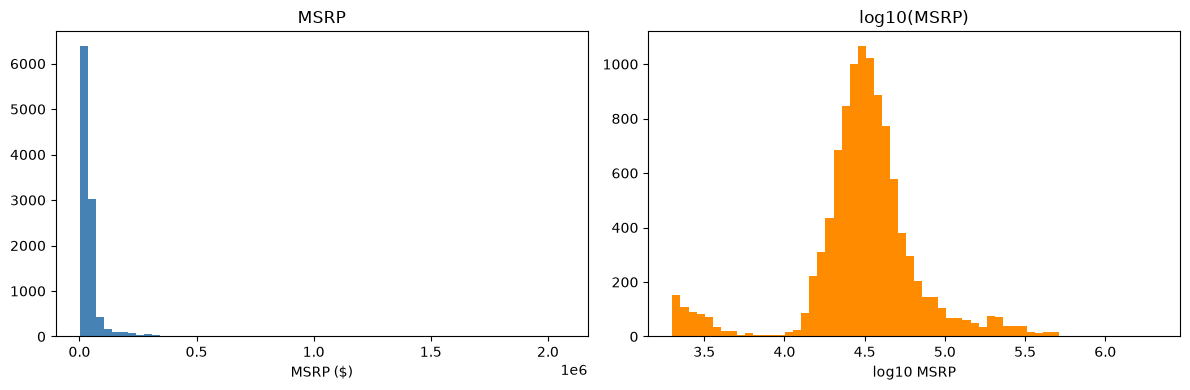

In [71]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(price, bins=60, color="steelblue")
ax[0].set_title("MSRP")
ax[0].set_xlabel("MSRP ($)")
ax[1].hist(np.log10(price), bins=60, color="darkorange")
ax[1].set_title("log10(MSRP)")
ax[1].set_xlabel("log10 MSRP")
plt.tight_layout() 
plt.show()

**Answer:**

a) Mean MSRP = **$44,789**, median = **$31,870**. The mean is bigger because a few very expensive cars (supercars up to $2M) pull it up, while the median ignores how extreme the tail is.

b) Raw MSRP is **strongly right-skewed**: a big pile at low prices and a long thin tail to the right. `log10(msrp)` is **one fairly symmetric hump** (a small tail on the cheap side), much closer to a bell shape.

c) Only **24.4%** of cars cost more than the mean, so the mean is above ~3 in 4 cars: not "typical".

d) Put the **median (~$32k)** on the homepage. It's the price the middle car actually sells at and isn't distorted by a handful of supercars.

### Q3. Fuel-efficient *for its size*?

Two 2017 cars:
- **Honda Civic** (Compact): 42 highway MPG
- **Volvo S90** (Large): 34 highway MPG

The Civic wins on raw MPG, but large cars are heavier. Which one is more impressive *for its class*?

a) For 2017 cars (only the MPG values you trust after Q1), compute the mean and standard deviation of highway MPG for each `vehicle_size`.

b) Compute each car's z-score within its own size class.

c) Which is more fuel-efficient for its class? How unusual is each one?

In [72]:
c17 = clean[(clean["year"] == 2017) & clean["highway_mpg"].notna()]
by_size = c17.groupby("vehicle_size")["highway_mpg"].agg(["count", "mean", "std"])
print(by_size.round(2))

              count   mean   std
vehicle_size                    
Compact         509  30.88  6.05
Large           468  22.99  3.49
Midsize         638  29.41  5.45


In [73]:
def z(value, size):
    return (value - by_size.loc[size, "mean"]) / by_size.loc[size, "std"]

print(f"Honda Civic (Compact, 42 mpg):  z = {z(42, 'Compact'):.2f}")
print(f"Volvo S90   (Large,   34 mpg):  z = {z(34, 'Large'):.2f}")

Honda Civic (Compact, 42 mpg):  z = 1.84
Volvo S90   (Large,   34 mpg):  z = 3.15


In [74]:
print(c17[c17["model"].isin(["Civic", "S90"])].groupby(["model", "vehicle_size"])["highway_mpg"].agg(["count", "max"]))

                    count   max
model vehicle_size             
Civic Compact          13  41.0
      Midsize          11  42.0
S90   Large             4  34.0


**Answer:**

For 2017 cars with trusted MPG, mean (std) highway MPG is **Compact 30.9 (6.1), Midsize 29.4 (5.5), Large 23.0 (3.5)**.

- Honda Civic (42 mpg, Compact): **z = +1.84**, so about 1.8 standard deviations above the average compact. Good, but not rare.
- Volvo S90 (34 mpg, Large): **z = +3.15**, so over 3 standard deviations above the average large car, which is very unusual.

The **Volvo S90 is the more fuel-efficient car for its class**, even though the Civic wins on raw MPG. Caveat: the Large class has a small spread (std 3.5), which inflates its z-scores, and the data labels the 42-mpg Civic sedan as *Midsize* (z = +2.3 there), but the S90 still wins.

---
## Part 3: Uncertainty

### Q4. How sure are we about the median price?

The 2017 cars are one snapshot of the market. With a slightly different set of cars, the median would move. A bootstrap shows how much.

a) Compute the median MSRP of 2017 cars.

b) Bootstrap it: resample the 2017 prices **with replacement** 5,000 times and take the median each time. Plot the 5,000 medians and report the 95% interval (2.5th and 97.5th percentiles).

c) Repeat for 2017 cars from **one make** with fewer than 50 cars that year (your choice). Is the interval wider or narrower? Why?

d) Explain the interval from (b) in one sentence a manager would understand.

In [75]:
def bootstrap_median(values, n_boot=5000):
    """Return an array of n_boot bootstrap medians."""
    values = np.asarray(values)
    draws = rng.choice(values, size=(n_boot, len(values)), replace=True)
    return np.median(draws, axis=1)

In [76]:
p17 = clean.loc[clean["year"] == 2017, "msrp"].dropna()
print(f"2017 cars: n = {len(p17)}, median MSRP = ${p17.median():,.0f}")
boots = bootstrap_median(p17)
lo, hi = np.percentile(boots, [2.5, 97.5])
print(f"95% bootstrap interval: ${lo:,.0f} to ${hi:,.0f}  (width ${hi-lo:,.0f})")

2017 cars: n = 1624, median MSRP = $36,738
95% bootstrap interval: $35,940 to $37,683  (width $1,743)


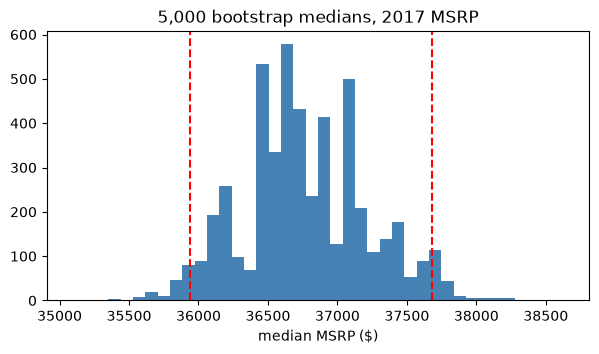

In [77]:
plt.figure(figsize=(7, 3.5))
plt.hist(boots, bins=40, color="steelblue")
plt.axvline(lo, color="red", ls="--"); plt.axvline(hi, color="red", ls="--")
plt.title("5,000 bootstrap medians, 2017 MSRP"); plt.xlabel("median MSRP ($)")
plt.show()

In [86]:
counts17 = clean[clean["year"] == 2017].groupby("make")["msrp"].count()
print(counts17[counts17 < 50].sort_values().tail(8).to_dict())
make = "Volvo"
pm = clean.loc[(clean["year"] == 2017) & (clean["make"] == make), "msrp"].dropna()
boots_m = bootstrap_median(pm)
lo_m, hi_m = np.percentile(boots_m, [2.5, 97.5])
print(f"{make} 2017: n = {len(pm)}, median = ${pm.median():,.0f}, 95% interval ${lo_m:,.0f} to ${hi_m:,.0f}  (width ${hi_m-lo_m:,.0f})")

{'Mitsubishi': 29, 'Lexus': 34, 'Acura': 36, 'Buick': 39, 'Hyundai': 42, 'Kia': 43, 'Lincoln': 46, 'Subaru': 46}
Volvo 2017: n = 23, median = $46,350, 95% interval $41,750 to $51,000  (width $9,250)


**Answer:**

a/b) The median MSRP of 1,624 cars from 2017 (after removing placeholders) is **$36,738**, and the bootstrap 95% interval is **$35,940 to $37,683**.

c) I used **Volvo** (23 priced cars in 2017). Its median is $46,350 with an interval of **$41,750 to $50,450**, about **5x wider** (width $8.7k vs. $1.7k). Fewer cars mean each resample is more variable, and a few cars can move the median a lot, so we are less sure.

d) "If we could re-draw the 2017 market many times, the median price would land between about $35.9k and $37.7k in 95% of those draws, so the typical price is pinned down to within roughly $2k."

---
## Part 4: Testing

### Q5. Can marketing say "our 2017 compacts average over 30 MPG"?

a) Write H₀ and Hₐ. One-sided or two-sided? Why?

b) How many cars are in the sample, and what does the distribution look like? Is a t-test reasonable here?

c) Run a one-sample t-test at α = 0.05 (`stats.ttest_1samp(..., alternative="greater")`). State the conclusion in plain English.

d) **Independence check.** Tests assume each row is an independent observation. Count how many rows each `make` + `model` has in this sample. Then average to one row per model and rerun the test. What changed, and which version do you trust more?

n = 509, mean = 30.88, median = 30.0, std = 6.05, skew = 0.58


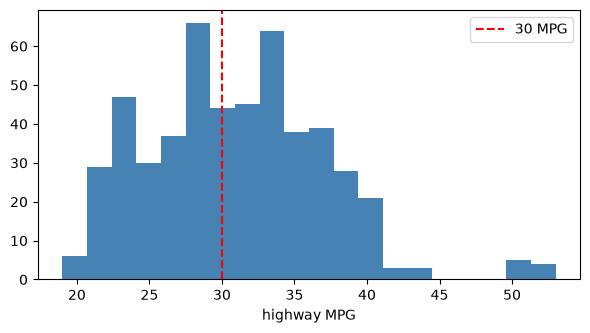

In [87]:
comp = clean[(clean["year"] == 2017) & (clean["vehicle_size"] == "Compact") & clean["highway_mpg"].notna()]
mpg = comp["highway_mpg"]
print(f"n = {len(mpg)}, mean = {mpg.mean():.2f}, median = {mpg.median():.1f}, std = {mpg.std():.2f}, skew = {mpg.skew():.2f}")
plt.figure(figsize=(7, 3.5))
plt.hist(mpg, bins=20, color="steelblue"); plt.axvline(30, color="red", ls="--", label="30 MPG")
plt.xlabel("highway MPG"); plt.legend(); plt.show()

In [88]:
t, p = stats.ttest_1samp(mpg, 30, alternative="greater")
print(f"t = {t:.2f}, p = {p:.2g}")

t = 3.28, p = 0.00055


In [89]:
per_model = comp.groupby(["make", "model"]).size().sort_values(ascending=False)
print(f"{len(per_model)} distinct models; rows per model: median {per_model.median():.0f}, max {per_model.max()}")
print(per_model.head(6))
one = comp.groupby(["make", "model"])["highway_mpg"].mean()
t2, p2 = stats.ttest_1samp(one, 30, alternative="greater")
print(f"\nOne row per model: n = {len(one)}, mean = {one.mean():.2f}, t = {t2:.2f}, p = {p2:.3g}")

85 distinct models; rows per model: median 6, max 27
make       model   
Toyota     Tacoma      27
Chevrolet  Corvette    24
Nissan     Frontier    22
           370Z        17
Porsche    911         14
Honda      Civic       13
dtype: int64

One row per model: n = 85, mean = 31.69, t = 2.58, p = 0.00585


**Answer:**

a) H₀: mean highway MPG of 2017 compacts = 30. Hₐ: mean > 30. **One-sided**, because marketing only wants to claim "over 30" and a result below 30 would not support it. (I used highway MPG: city MPG averages are far below 30 for every class.)

b) n = **509** cars, mean 30.9, median 30, std 6.1. The distribution is a bit right-skewed (skew 0.58) but unimodal. With n = 509 the Central Limit Theorem makes the t-test reasonable.

c) t = 3.28, **p = 0.0006 < 0.05**, so we reject H₀: a naive test says the compact average is over 30 MPG.

d) The 509 rows come from only **85 distinct models** (median 6 rows each, up to 27 for Toyota Tacoma), so rows are not independent: one model with many trims is counted many times. Averaging to one row per model gives n = 85, mean 31.7, **t = 2.58, p = 0.006**. It is still significant, but the evidence is weaker (p is 10x larger). **I trust the per-model version more**, since its observations are closer to independent. Marketing can say it, but with the caveat that it is an average across models, not sales-weighted.

### Q6. Do manual cars cost less? (the big one)

A sales rep says: *"Manual cars are way cheaper. We should push manuals to budget shoppers."*

Compare `AUTOMATIC` vs `MANUAL` only.

a) Compare the median MSRP of the two groups.

b) Before believing it, compare the `year` of manual vs automatic cars. What do you notice?

c) Redo (a) using only 2015–2017 cars, then within each `vehicle_size`. For 2015–17 compacts, use the Mann–Whitney U test (`stats.mannwhitneyu(auto, manual)`) to compare prices.

- What do the p-value and medians suggest?

d) Write one sentence back to the sales rep.

In [90]:
am = clean[clean["transmission_type"].isin(["AUTOMATIC", "MANUAL"]) & clean["msrp"].notna()]
print(am.groupby("transmission_type")["msrp"].agg(["count", "median"]))

                   count   median
transmission_type                
AUTOMATIC           7635  33620.0
MANUAL              2184  21875.0


In [91]:
print(am.groupby("transmission_type")["year"].agg(["median", "mean"]).round(1))
print("Share of cars from 2015-17:\n", am.groupby("transmission_type")["year"].apply(lambda s: (s >= 2015).mean()).round(2))


                   median    mean
transmission_type                
AUTOMATIC          2015.0  2012.5
MANUAL             2011.0  2009.1
Share of cars from 2015-17:
 transmission_type
AUTOMATIC    0.59
MANUAL       0.37
Name: year, dtype: float64


In [92]:
rec = am[am["year"].between(2015, 2017)]
print("\n2015-17 overall:\n", rec.groupby("transmission_type")["msrp"].agg(["count", "median"]))
print("\n2015-17 by vehicle_size:\n", rec.pivot_table(index="vehicle_size", columns="transmission_type", values="msrp", aggfunc=["count", "median"]))


2015-17 overall:
                    count   median
transmission_type                
AUTOMATIC           4511  37065.0
MANUAL               813  26905.0

2015-17 by vehicle_size:
                       count           median         
transmission_type AUTOMATIC MANUAL AUTOMATIC   MANUAL
vehicle_size                                         
Compact                1119    589   25995.0  25860.0
Large                  1473     26   44400.0  38395.0
Midsize                1919    198   37980.0  26920.0


In [93]:
rc = rec[rec["vehicle_size"] == "Compact"]
auto, manual = rc.loc[rc["transmission_type"] == "AUTOMATIC", "msrp"], rc.loc[rc["transmission_type"] == "MANUAL", "msrp"]
u, p = stats.mannwhitneyu(auto, manual)
print(f"\nCompacts 2015-17: auto n={len(auto)} median=${auto.median():,.0f}; manual n={len(manual)} median=${manual.median():,.0f}; U={u:.0f}, p={p:.3g}")


Compacts 2015-17: auto n=1119 median=$25,995; manual n=589 median=$25,860; U=317261, p=0.205


**Answer:**

a) Median MSRP: automatic **$33,620**, manual **$21,875**. That looks like a $11.7k gap.

b) Manuals are **older**: median year 2011 vs. 2015 for automatics, and only 37% of manuals are from 2015-17 vs. 59% of automatics. Older cars sold for less back then, so the year is confounding the comparison.

c) Restricted to 2015-17, the gap shrinks from $11.7k to ~$10k overall (still large), because manuals are concentrated in cheaper segments. Within vehicle size: Compact $25,995 auto vs. $25,860 manual (essentially identical), Midsize $37,980 vs. $26,920, Large $44,400 vs. $38,395 (but only 26 manuals). For 2015-17 compacts, the Mann-Whitney test gives **p = 0.21**, so no evidence of a price difference. Compacts are the one size class with lots of manuals (589).

d) *"Manuals look cheaper mostly because they're older and concentrated in small, cheap cars. Comparing like with like (same years, compacts), the price difference is basically zero, so don't pitch manuals as a budget option."*

### Q7. Significant ≠ important

Among cars whose MPG you trust, 4-door cars get better highway MPG than 2-door cars.

a) Run a Welch t-test. Report the difference in means and the p-value.

b) Translate the difference into dollars. Assume 12,000 miles/year and \$3.50/gallon. How much does the average 4-door driver save per year?

c) Now pretend you only had **30 cars per group.** Draw 30 random 4-door and 30 random 2-door cars, run the same test, and repeat 1,000 times. What fraction of those tests come out significant (p < 0.05)?

d) Would you put "4-door cars are significantly more fuel-efficient" in an ad? What would you say instead?

In [94]:
d = clean[clean["number_of_doors"].isin([2, 4]) & clean["highway_mpg"].notna()]
four, two = d.loc[d["number_of_doors"] == 4, "highway_mpg"], d.loc[d["number_of_doors"] == 2, "highway_mpg"]
t, p = stats.ttest_ind(four, two, equal_var=False)
print(f"4-door: n={len(four)}, mean={four.mean():.2f} | 2-door: n={len(two)}, mean={two.mean():.2f}")
print(f"difference = {four.mean()-two.mean():.2f} mpg, t = {t:.2f}, p = {p:.3g}")

4-door: n=7897, mean=26.80 | 2-door: n=2873, mean=25.26
difference = 1.55 mpg, t = 11.93, p = 2.11e-32


In [95]:
miles, ppg = 12_000, 3.50
cost4, cost2 = (miles * ppg / four).mean(), (miles * ppg / two).mean()
print(f"avg yearly fuel cost: 4-door ${cost4:,.0f}, 2-door ${cost2:,.0f}, saving ${cost2-cost4:,.0f}/yr")

avg yearly fuel cost: 4-door $1,650, 2-door $1,758, saving $108/yr


In [96]:
n_sims, hits = 1000, 0
for _ in range(n_sims):
    a = rng.choice(four.to_numpy(), 30, replace=False)
    b = rng.choice(two.to_numpy(), 30, replace=False)
    if stats.ttest_ind(a, b, equal_var=False).pvalue < 0.05:
        hits += 1
print(f"{hits / n_sims:.1%} of {n_sims} small-sample tests were significant")

17.1% of 1000 small-sample tests were significant


**Answer:**

a) 4-door cars average 26.80 mpg vs. 25.26 for 2-door cars (n = 7,897 vs. 2,873), a difference of **1.55 mpg**, Welch t = 11.9, **p ≈ 2e-32**. It is extremely statistically significant.

b) At 12,000 miles/year and $3.50/gal, the average 4-door driver spends about $1,650/yr on fuel vs. $1,758 for 2-door, a saving of about **$108/year** (~$9/month).

c) With only 30 cars per group, just **~16%** of the 1,000 tests came out significant (p < 0.05). The effect is real, but it is small compared to the spread between cars, so a small sample usually misses it (low power). Significance in the full data comes from sheer sample size.

d) I would **not** write "significantly more fuel-efficient" in an ad: customers hear "significant" as "big", and ~1.5 mpg / ~$100 a year isn't much (and 4-doors differ from 2-doors in many other ways, like size and type). Instead: *"4-door cars average about 1.5 more highway MPG, roughly $100 a year in gas."*

---
## Part 5: Communicate

### Q8. Your memo to the pricing manager

Write 4–6 sentences. Include:
- Your answer to "do manual cars cost less?", with at least one number
- One other finding from this notebook that matters for pricing
- One limitation of this data a manager should know about

No unexplained jargon: if you say "significant," say what it means.

**Memo:**

Manual cars look much cheaper (median $21.9k vs. $33.6k), but that gap is mostly misleading: manuals in this data are older (median 2011 vs. 2015) and concentrated in cheaper car types. Among 2015-17 compacts, automatic and manual medians are almost identical ($26.0k vs. $25.9k, test p = 0.21, meaning the gap is well within what chance produces), so we should not market manuals as the budget choice. For pricing, the typical car costs about $31.9k (the median) rather than the mean of $44.8k, which is pulled up by a few supercars, and 2017's median price is known to within about ±$900. One limitation is that the data is a list of car trims from 2015-17 (about half the rows) and not actual sales, and the prices are sticker prices (MSRP), so it can't tell us what cars really sell for or how popular each one is. I also had to discard or blank about 750 placeholder prices ($2,000) and all electric-car MPG, so conclusions about those cars are limited.

---
## 🚀 Stretch (optional)

### 🚀 S1. Horsepower and price

a) Compute the correlation between `engine_hp` and `msrp` three ways: Pearson, Pearson with `np.log10(msrp)`, and Spearman. Why do they differ?

b) Scatter plot HP vs MSRP with a log y-axis (`plt.yscale("log")`).

c) Does adding horsepower *cause* a higher price? Name one lurking variable.

n = 10378
Pearson (HP, MSRP):         0.650
Pearson (HP, log10 MSRP):   0.698
Spearman (HP, MSRP):        0.822


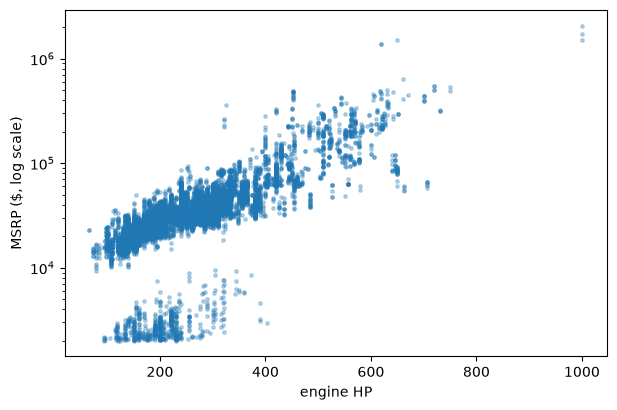

In [97]:
h = clean[["engine_hp", "msrp"]].dropna()
print(f"n = {len(h)}")
print(f"Pearson (HP, MSRP):         {h['engine_hp'].corr(h['msrp']):.3f}")
print(f"Pearson (HP, log10 MSRP):   {h['engine_hp'].corr(np.log10(h['msrp'])):.3f}")
print(f"Spearman (HP, MSRP):        {h['engine_hp'].corr(h['msrp'], method='spearman'):.3f}")

plt.figure(figsize=(7, 4.5))
plt.scatter(h["engine_hp"], h["msrp"], s=6, alpha=0.3)
plt.yscale("log"); plt.xlabel("engine HP"); plt.ylabel("MSRP ($, log scale)")
plt.show()

**Answer:**

a) Pearson (HP, MSRP) = **0.65**, Pearson with log10(MSRP) = **0.70**, Spearman = **0.82**. Pearson on raw price is dragged down by the extreme prices (a few supercars) and by the curved (not straight-line) relationship. Taking the log straightens the curve and tames outliers, so it rises. Spearman uses only ranks, so it ignores both the curve and the outliers and just asks "does more HP tend to mean higher price?", and the answer is: very consistently.

b) The log-scale scatter shows a clear upward trend with a wide band: price rises steadily with HP, with lots of scatter at any given HP.

c) **Not necessarily.** Bolting on horsepower doesn't by itself set the price. A lurking variable is **brand / luxury level** (or car class): luxury and sports brands build more powerful engines *and* charge more for the badge, interior and tech. Vehicle size and year are other candidates.

### 🚀 S2. Is transmission tied to vehicle size?

For 2015–2017 cars (automatic and manual only), build a crosstab of `vehicle_size` × `transmission_type` and run a chi-square test (`stats.chi2_contingency`). How does this connect to Q6?

In [98]:
r = clean[clean["year"].between(2015, 2017) & clean["transmission_type"].isin(["AUTOMATIC", "MANUAL"])]
ct = pd.crosstab(r["vehicle_size"], r["transmission_type"])
print(ct)
print((ct.div(ct.sum(axis=1), axis=0) * 100).round(1).rename(columns=lambda c: c + " %"))
chi2, p, dof, _ = stats.chi2_contingency(ct)
print(f"chi2 = {chi2:.1f}, dof = {dof}, p = {p:.3g}")

transmission_type  AUTOMATIC  MANUAL
vehicle_size                        
Compact                 1119     589
Large                   1473      26
Midsize                 1919     198
transmission_type  AUTOMATIC %  MANUAL %
vehicle_size                            
Compact                   65.5      34.5
Large                     98.3       1.7
Midsize                   90.6       9.4
chi2 = 756.9, dof = 2, p = 4.31e-165


**Answer:**

Share of manuals in 2015-17: **Compact 34.5%, Midsize 9.4%, Large 1.7%**. The chi-square test gives chi2 = 757, dof = 2, **p ≈ 4e-165**, so transmission type and vehicle size are strongly related. This links to Q6: manuals are concentrated in compact (cheaper) cars, while larger and pricier cars are almost all automatic. So "manual vs. automatic" is partly "small car vs. big car" in disguise, which is why the raw price gap disappears once you compare within a size class.